In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [ ]:
from numpy.random.mtrand import f
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path="/content/drive/MyDrive/Celestial/K-means/dataset/synthetic_mall_customers.csv"
df=pd.read_csv(file_path)

df.head()

,CustomerID,Gender,Age,Annual_Income_k$,Spending_Score,Visit_Frequency_per_Month,Online_Engagement_Score,Preferred_Section,Latent_Group
0,1001,Female,31.0,58.0,70.1,12.5,64.6,Fashion,Young high spenders
1,1002,Female,25.0,67.1,75.0,10.6,98.2,Electronics,Young high spenders
2,1003,Female,19.0,42.1,86.2,11.0,86.1,Fashion,Young high spenders
3,1004,Female,20.0,28.1,66.1,6.3,91.3,Electronics,Young high spenders
4,1005,Male,21.0,16.7,78.3,11.9,75.7,Luxury,Young high spenders


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual_Income_k$,Spending_Score,Visit_Frequency_per_Month,Online_Engagement_Score,Preferred_Section,Latent_Group
239,1240,Female,25.0,94.3,96.8,14.2,99.4,Luxury,Premium loyal customers
240,1242,Female,23.0,172.0,99.0,17.5,97.0,Luxury,Outlier
241,1243,Male,NaN,14.0,6.0,1.0,8.0,Groceries,Outlier
242,1244,Female,52.0,140.0,18.0,2.0,22.0,Electronics,Outlier
243,1245,Male,19.0,24.0,98.0,16.0,95.0,Fashion,Outlier


3. Read the Data and Understand the Columns

In [ ]:
print(df.shape)

print(df.dtypes)


(244, 9)
CustomerID                     int64
Gender                        object
Age                          float64
Annual_Income_k$             float64
Spending_Score               float64
Visit_Frequency_per_Month    float64
Online_Engagement_Score      float64
Preferred_Section             object
Latent_Group                  object
dtype: object


In [ ]:
print(df.isnull().sum())

CustomerID                    0
Gender                        0
Age                           9
Annual_Income_k$             12
Spending_Score                9
Visit_Frequency_per_Month     0
Online_Engagement_Score       7
Preferred_Section             7
Latent_Group                  0
dtype: int64


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,244.0,NaN,NaN,NaN,1122.516393,70.609018,1001.0,1061.75,1122.5,1183.25,1245.0
Gender,244,2,Female,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,235.0,NaN,NaN,NaN,33.668085,8.160283,18.0,28.0,34.0,39.0,53.0
Annual_Income_k$,232.0,NaN,NaN,NaN,63.760345,33.517942,14.0,34.05,51.6,92.9,172.0
Spending_Score,235.0,NaN,NaN,NaN,58.12383,24.177818,6.0,36.2,52.2,79.85,100.0
Visit_Frequency_per_Month,244.0,NaN,NaN,NaN,8.495492,3.225532,1.0,6.1,8.8,10.8,17.5
Online_Engagement_Score,237.0,NaN,NaN,NaN,63.240506,24.019001,8.0,43.5,60.1,86.0,100.0
Preferred_Section,237,4,Luxury,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latent_Group,244,5,Young high spenders,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Separate column types for easier analysis
numeric_cols = [
    "Age",
    "Annual_Income_k$",
    "Spending_Score",
    "Visit_Frequency_per_Month",
    "Online_Engagement_Score",
]

categorical_cols = ["Gender", "Preferred_Section"]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,235.0,33.668085,8.160283,18.0,28.00,34.0,39.00,53.0
Annual_Income_k$,232.0,63.760345,33.517942,14.0,34.05,51.6,92.90,172.0
Spending_Score,235.0,58.123830,24.177818,6.0,36.20,52.2,79.85,100.0
Visit_Frequency_per_Month,244.0,8.495492,3.225532,1.0,6.10,8.8,10.80,17.5
Online_Engagement_Score,237.0,63.240506,24.019001,8.0,43.50,60.1,86.00,100.0


In [ ]:
# Visualize missing values as percentages
missing_summary = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary

,column,missing_percent
0,Annual_Income_k$,4.918033
1,Spending_Score,3.688525
2,Age,3.688525
3,Preferred_Section,2.868852
4,Online_Engagement_Score,2.868852
5,CustomerID,0.000000
6,Gender,0.000000
7,Visit_Frequency_per_Month,0.000000
8,Latent_Group,0.000000


/tmp/ipykernel_6365/96560656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", ax=axes[0], palette="Set2")
/tmp/ipykernel_6365/96560656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Preferred_Section", ax=axes[1], palette="Set3")


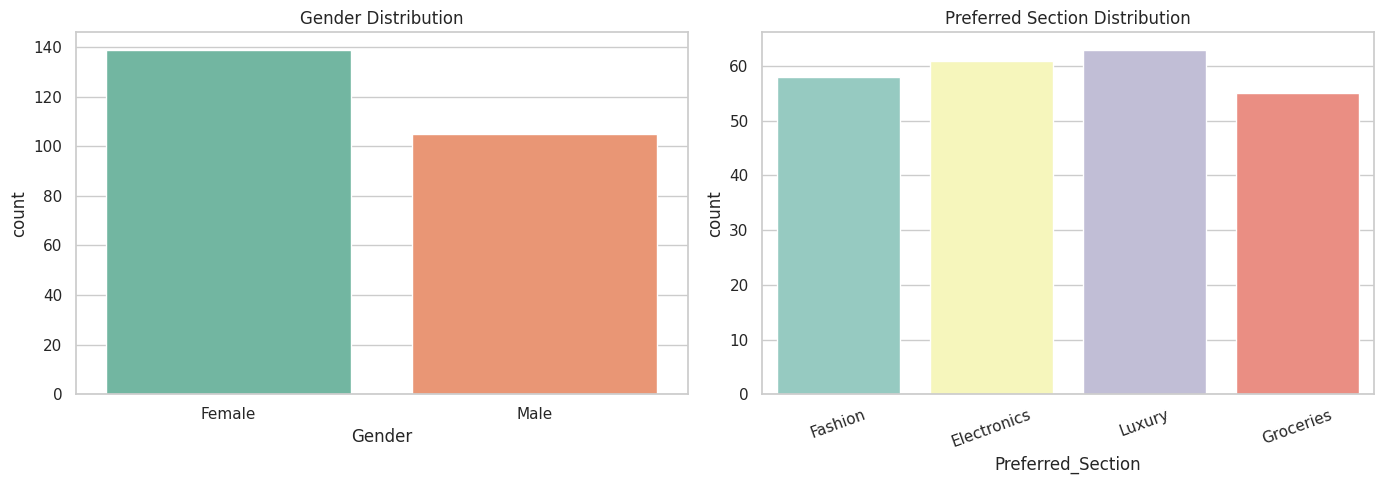

In [ ]:
# Count plots for categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Gender", ax=axes[0], palette="Set2")
axes[0].set_title("Gender Distribution")

sns.countplot(data=df, x="Preferred_Section", ax=axes[1], palette="Set3")
axes[1].set_title("Preferred Section Distribution")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

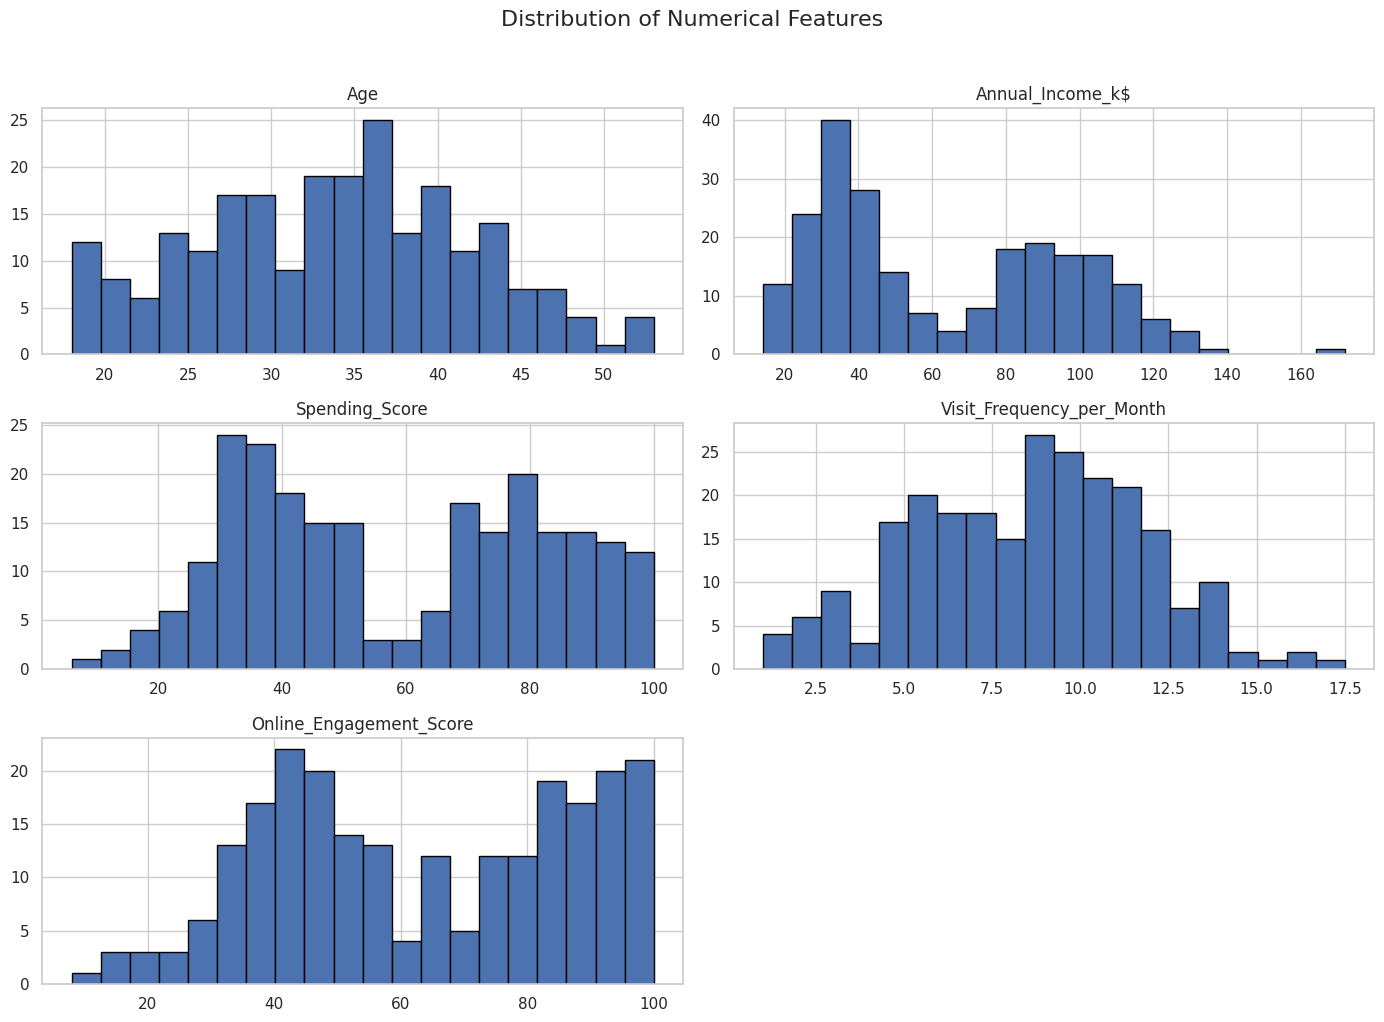

In [ ]:
# Histograms to understand the spread of numerical variables
df[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

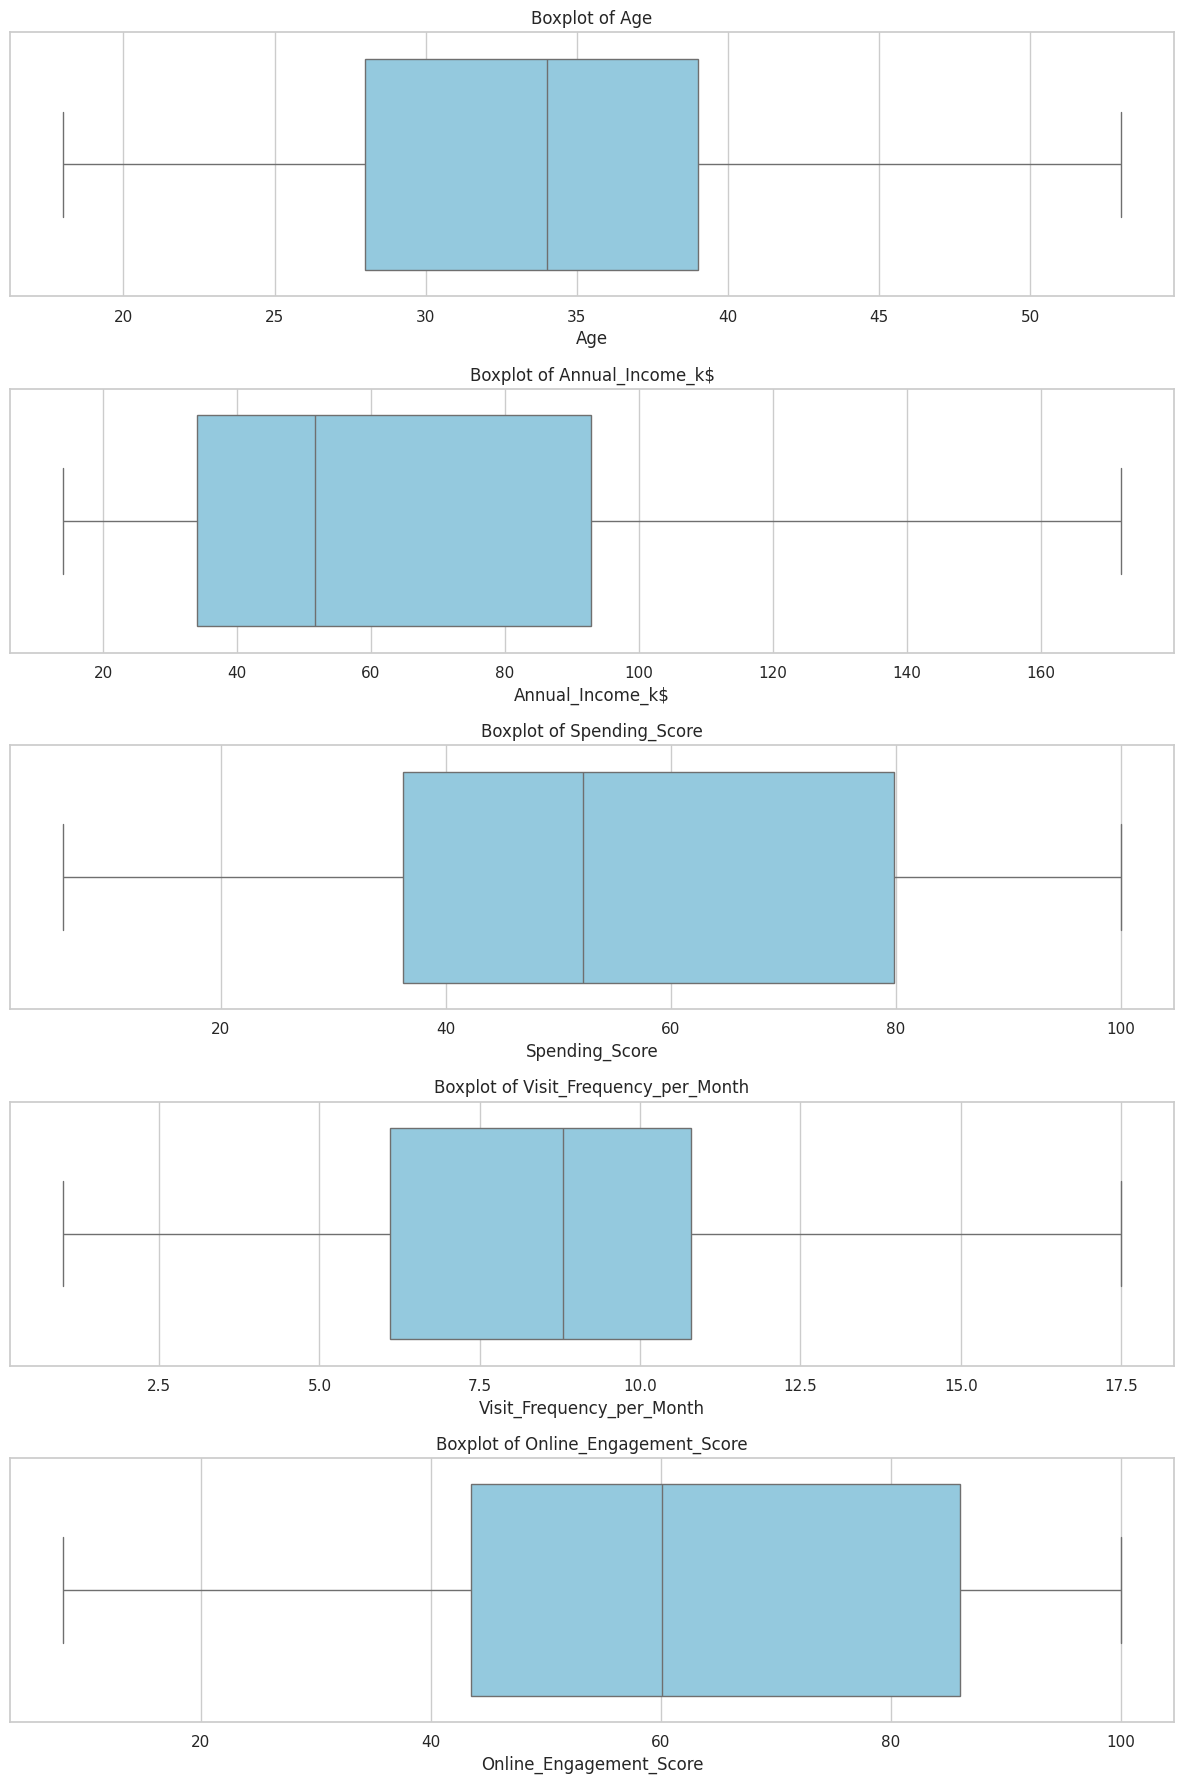

In [ ]:
#check the outlier using box plot
fig, axes = plt.subplots(len(numeric_cols),1,figsize=(12,18))
for ax, col in zip(axes, numeric_cols):
  sns.boxplot(data=df, x=col, ax=ax, color="skyblue")
  ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
# sns.pairplot(df[numeric_cols])
# plt.show()

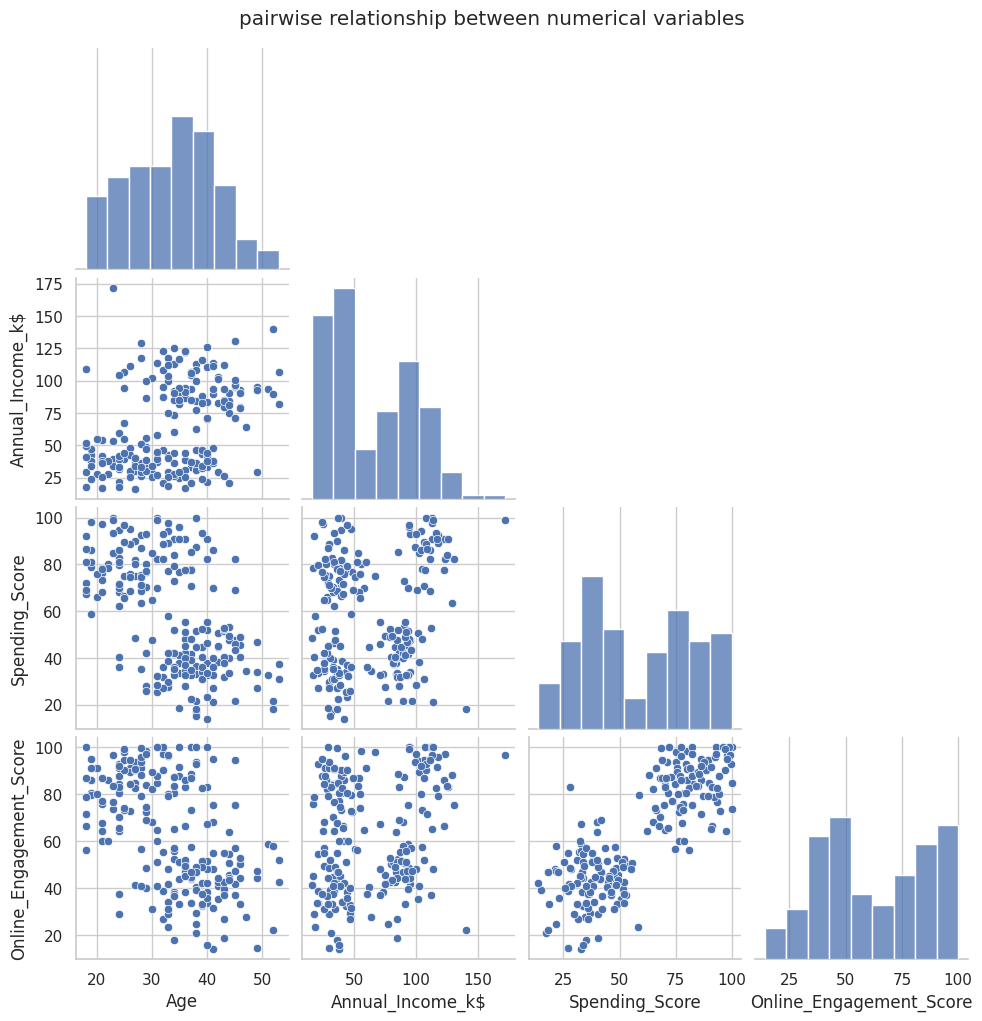

In [ ]:
# pairplot to check relationship among numerical varables
pairplot_cols =["Age","Annual_Income_k$","Spending_Score","Online_Engagement_Score"]
sns.pairplot(df[pairplot_cols].dropna(),corner=True,diag_kind="hist")
plt.suptitle("pairwise relationship between numerical variables",y=1.02)
plt.show()

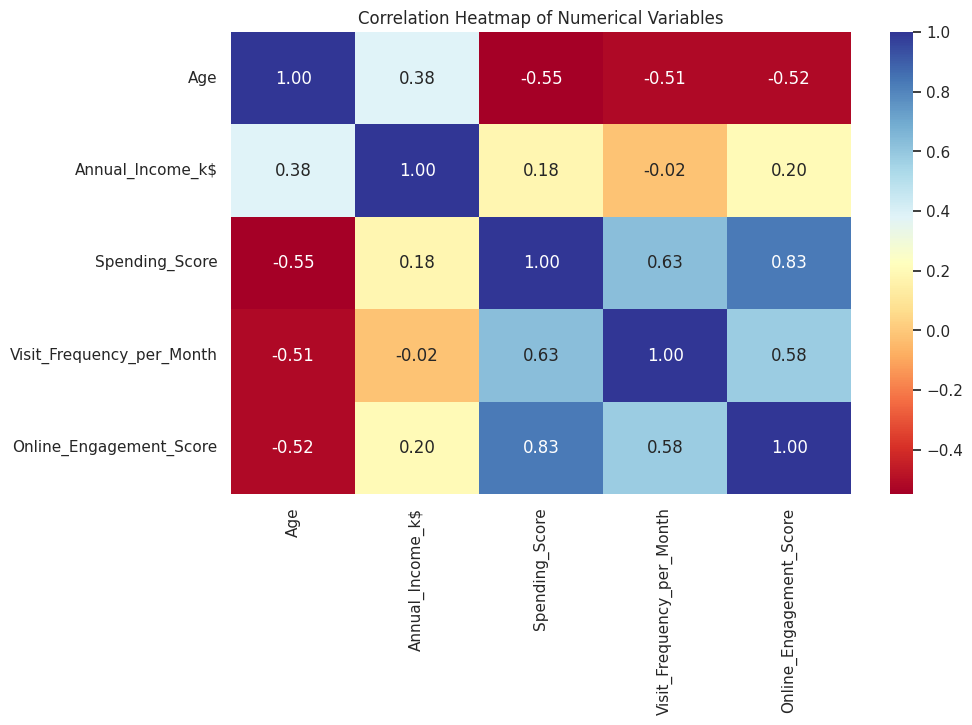

In [ ]:
#correlation heatmap for all numerical variables
plt.figure(figsize=(10,6))
correlation_matrix=df[numeric_cols].corr()
sns.heatmap(correlation_matrix,annot=True,cmap="RdYlBu",fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

EDA interpretation
check mising values
check outlier values
are variables on idfferent scales
are there visible groupings

In [ ]:
#IQR- based outlier counting
def count_outlier_iqr(series):
  q1=series.quantile(0.25)
  q3=series.quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5* iqr
  upper=q3-1.5* iqr

  mask=(series < lower) | (series > upper)
  return int(mask.sum()),lower, upper


In [ ]:
outlier_rows =[]

for col in numeric_cols:
  non_null_series = df[col].dropna()
  count, lower, upper = count_outlier_iqr(non_null_series)
  outlier_rows.append(
      {
          "feature":col,
          "outlier_count": count,
          "lower_bound":round(lower,2),
          "upper_bound":round(upper,2),
      }
  )

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,feature,outlier_count,lower_bound,upper_bound
0,Age,213,11.50,22.50
1,Annual_Income_k$,232,-54.23,4.62
2,Spending_Score,233,-29.27,14.38
3,Visit_Frequency_per_Month,225,-0.95,3.75
4,Online_Engagement_Score,229,-20.25,22.25


Data Preprocessing
step A: droping columns that should not influence clustering
now drop : customerID, latent_Group

step B: handling missing values

for this i using  median imputation for numerical columns
most fregent imputation for categorical columns

why median ?
because median is less sensitive to outliers than mean

step c : Handle outliers

here remove the outliers
cap outliers
keep them and justify it  here we cap them using IQR method


step D : encoding categorical variables

in this k means require numeric input so that used one-hot encoding for categorical columns

step E:  scale the numerical features

we use StandardScaler
 mean = 0
 std deviation = 1

step A: droping columns that should not influence clustering
now drop : customerID, latent_Group

In [ ]:
#create a working copy
data = df.drop(columns=["CustomerID", "Latent_Group"]).copy()

step B: handling missing values

for this i using median imputation for numerical columns most fregent imputation for categorical columns

why median ? because median is less sensitive to outliers than mean

In [ ]:
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
cat_cols = data.select_dtypes(include=["object"]).columns

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

step c : Handle outliers

here remove the outliers cap outliers keep them and justify it here we cap them using IQR method

In [ ]:
# Cap outliers using IQR bounds
def cap_outliers_iqr(frame, columns):
    capped = frame.copy()
    bounds = {}
    for col in columns:
        series = capped[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        capped[col] = capped[col].clip(lower=lower, upper=upper)
        bounds[col] = (lower, upper)
    return capped, bounds

data_capped, iqr_bounds = cap_outliers_iqr(data, numeric_cols)

# Show capping bounds
pd.DataFrame(
    {
        "feature": list(iqr_bounds.keys()),
        "lower_cap": [round(v[0], 2) for v in iqr_bounds.values()],
        "upper_cap": [round(v[1], 2) for v in iqr_bounds.values()],
    }
)


,feature,lower_cap,upper_cap
0,Age,11.50,55.50
1,Annual_Income_k$,-52.48,179.12
2,Spending_Score,-26.74,142.36
3,Visit_Frequency_per_Month,-0.95,17.85
4,Online_Engagement_Score,-18.12,146.88


step D : encoding categorical variables

in this k means require numeric input so that used one-hot encoding for categorical columns

In [ ]:
# # Identify categorical columns
# cat_cols = data_capped.select_dtypes(include=["object"]).columns

# # Apply One-Hot Encoding
# data_encoded = pd.get_dummies(data_capped, columns=cat_cols, drop_first=True)

In [ ]:
print(data_encoded.head())

    Age  Annual_Income_k$  Spending_Score  Visit_Frequency_per_Month  \
0  31.0              58.0            70.1                       12.5   
1  25.0              67.1            75.0                       10.6   
2  19.0              42.1            86.2                       11.0   
3  20.0              28.1            66.1                        6.3   
4  21.0              16.7            78.3                       11.9   

   Online_Engagement_Score  Gender_Male  Preferred_Section_Fashion  \
0                     64.6        False                       True   
1                     98.2        False                      False   
2                     86.1        False                       True   
3                     91.3        False                      False   
4                     75.7         True                      False   

   Preferred_Section_Groceries  Preferred_Section_Luxury  
0                        False                     False  
1                        Fal

In [ ]:
# data_encoded = data_encoded.astype(int)

# print(data_encoded.head())

   Age  Annual_Income_k$  Spending_Score  Visit_Frequency_per_Month  \
0   31                58              70                         12   
1   25                67              75                         10   
2   19                42              86                         11   
3   20                28              66                          6   
4   21                16              78                         11   

   Online_Engagement_Score  Gender_Male  Preferred_Section_Fashion  \
0                       64            0                          1   
1                       98            0                          0   
2                       86            0                          1   
3                       91            0                          0   
4                       75            1                          0   

   Preferred_Section_Groceries  Preferred_Section_Luxury  
0                            0                         0  
1                            0    

step E: scale the numerical features

we use StandardScaler mean = 0 std deviation = 1

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data_encoded)

# # Convert back to DataFrame
# data_scaled = pd.DataFrame(data_scaled, columns=data_encoded.columns)

In [ ]:
# Build preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_processed = preprocessor.fit_transform(data_capped)

print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (244, 9)


8. convert to dence format

In [ ]:
# convert sparse metrix to dense numpy array
X_dense=X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed
# get feature names here retrieves column names after transformation
feature_names = preprocessor.get_feature_names_out()
# convert to dataframe
processed_Df=pd.DataFrame(X_dense,columns=feature_names)
processed_Df.head()


,num__Age,num__Annual_Income_k$,num__Spending_Score,num__Visit_Frequency_per_Month,num__Online_Engagement_Score,cat__Gender_Male,cat__Preferred_Section_Fashion,cat__Preferred_Section_Groceries,cat__Preferred_Section_Luxury
0,-0.335395,-0.157778,0.514467,1.244055,0.061351,0.0,1.0,0.0,0.0
1,-1.086187,0.120350,0.721188,0.653794,1.483406,0.0,0.0,0.0,0.0
2,-1.836979,-0.643739,1.193692,0.778060,0.971297,0.0,1.0,0.0,0.0
3,-1.711847,-1.071630,0.345716,-0.682060,1.191377,0.0,0.0,0.0,0.0
4,-1.586715,-1.420055,0.860408,1.057657,0.531137,1.0,0.0,0.0,1.0


9. Choosing the number of clusters for k means

In [ ]:
# Evaluate K-Means for a range of cluster counts
cluster_range = range(2, 9)
inertia_values = []
silhouette_values = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_processed)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_processed, labels))

evaluation_df = pd.DataFrame(
    {
        "k": list(cluster_range),
        "inertia": inertia_values,
        "silhouette_score": silhouette_values,
    }
)

evaluation_df

,k,inertia,silhouette_score
0,2,826.205842,0.365983
1,3,661.817436,0.343875
2,4,535.286930,0.301356
3,5,506.528311,0.265530
4,6,479.249056,0.198517
5,7,457.842668,0.171275
6,8,439.267545,0.160540


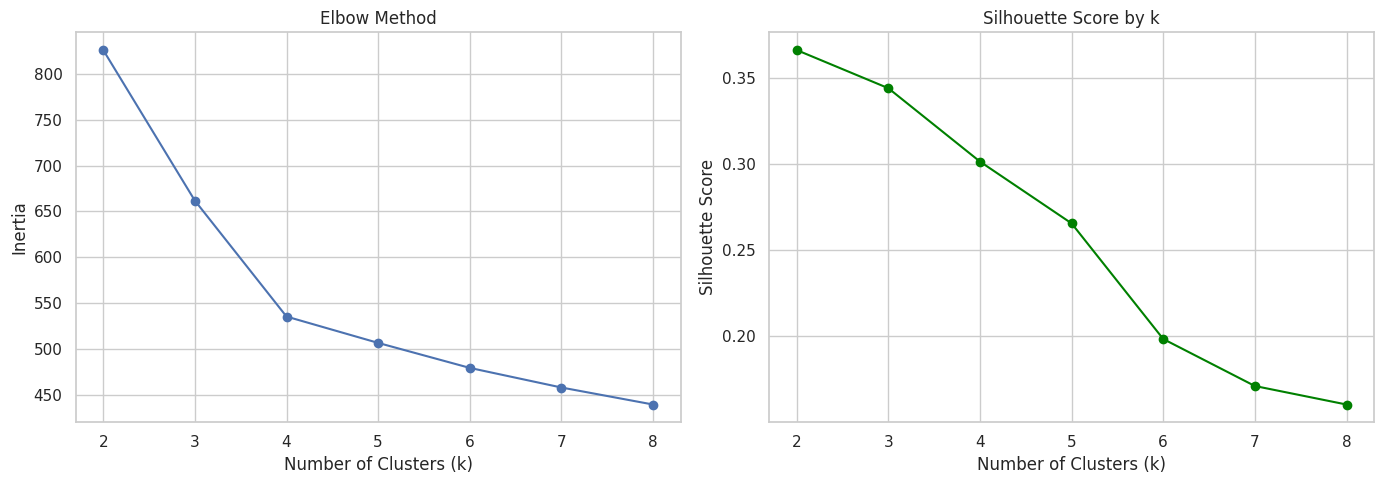

In [ ]:
# Plot Elbow Method and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cluster_range, inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(cluster_range, silhouette_values, marker="o", color="green")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [ ]:
# Select the best k based on silhouette score
#best_k = evaluation_df.loc[evaluation_df["silhouette_score"].idxmax(), "k"]
best_k = 5
print("Best k based on silhouette score:", int(best_k))

Best k based on silhouette score: 5


10.fit the final k-means model

In [ ]:
final_kmeans=KMeans(n_clusters=int(best_k),random_state=42,n_init=20)
kmeans_labels=final_kmeans.fit_predict(X_processed)

results= data_capped.copy()
results["KMeans_Cluster"] = kmeans_labels

results.head()

,Gender,Age,Annual_Income_k$,Spending_Score,Visit_Frequency_per_Month,Online_Engagement_Score,Preferred_Section,KMeans_Cluster
0,Female,31.0,58.0,70.1,12.5,64.6,Fashion,1
1,Female,25.0,67.1,75.0,10.6,98.2,Electronics,1
2,Female,19.0,42.1,86.2,11.0,86.1,Fashion,1
3,Female,20.0,28.1,66.1,6.3,91.3,Electronics,1
4,Male,21.0,16.7,78.3,11.9,75.7,Luxury,1


In [ ]:
# Evaluate final K-Means model
final_inertia = final_kmeans.inertia_
final_silhouette = silhouette_score(X_processed, kmeans_labels)

print("Final K-Means Inertia:", round(final_inertia, 2))
print("Final K-Means Silhouette Score:", round(final_silhouette, 4))

Final K-Means Inertia: 506.53
Final K-Means Silhouette Score: 0.2655


In [ ]:
centroids = final_kmeans.cluster_centers_

### Visualize K-Means Clusters
To visualize the clusters, we'll first reduce the dimensionality of our `X_processed` data using Principal Component Analysis (PCA) to two components. This allows us to plot the clusters on a 2D scatter plot.

The scatter plot will show the data points colored according to their assigned K-Means cluster, providing a visual representation of the clustering results.

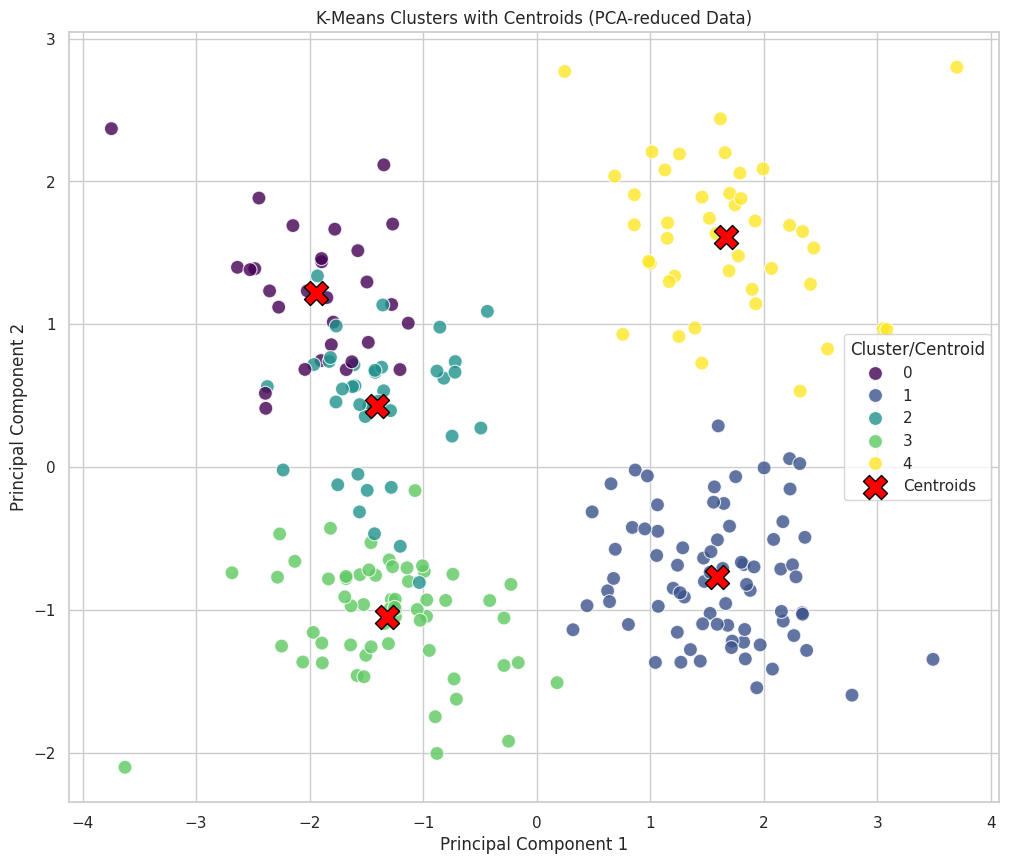

In [ ]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Transform centroids to the same PCA space
centroids_pca = pca.transform(centroids)

# Create a DataFrame for PCA results and cluster labels
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['KMeans_Cluster'] = kmeans_labels

# Plot the clusters
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='KMeans_Cluster',
    data=pca_df,
    palette='viridis',
    s=100,  # size of points
    alpha=0.8, # transparency
    edgecolor='w' # white edge for points
)

# Plot the centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=300, # size of centroid markers
    c='red', # color of centroids
    edgecolor='black',
    label='Centroids'
)
plt.title('K-Means Clusters with Centroids (PCA-reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster/Centroid')
plt.grid(True)
plt.show()

In [ ]:
# Cluster profiling to understand what each cluster represents
numeric_profile = results.groupby("KMeans_Cluster")[numeric_cols].mean().round(2)
categorical_profile = results.groupby("KMeans_Cluster")[categorical_cols].agg(
    lambda x: x.mode(dropna=True).iloc[0] if not x.mode(dropna=True).empty else np.nan
)

cluster_profile = numeric_profile.join(categorical_profile)
cluster_profile

,Age,Annual_Income_k$,Spending_Score,Visit_Frequency_per_Month,Online_Engagement_Score,Gender,Preferred_Section
KMeans_Cluster,,,,,,,
0,45.97,92.30,40.94,5.36,43.95,Female,Luxury
1,25.65,39.43,77.21,10.30,82.41,Female,Electronics
2,37.49,80.65,40.56,5.16,50.74,Male,Fashion
3,35.66,33.90,34.14,7.78,38.65,Female,Groceries
4,33.21,110.30,84.63,11.55,87.96,Female,Luxury


In [ ]:
# Cluster sizes
cluster_sizes = results["KMeans_Cluster"].value_counts().sort_index()
cluster_sizes

,count
KMeans_Cluster,
0,29
1,75
2,39
3,59
4,42


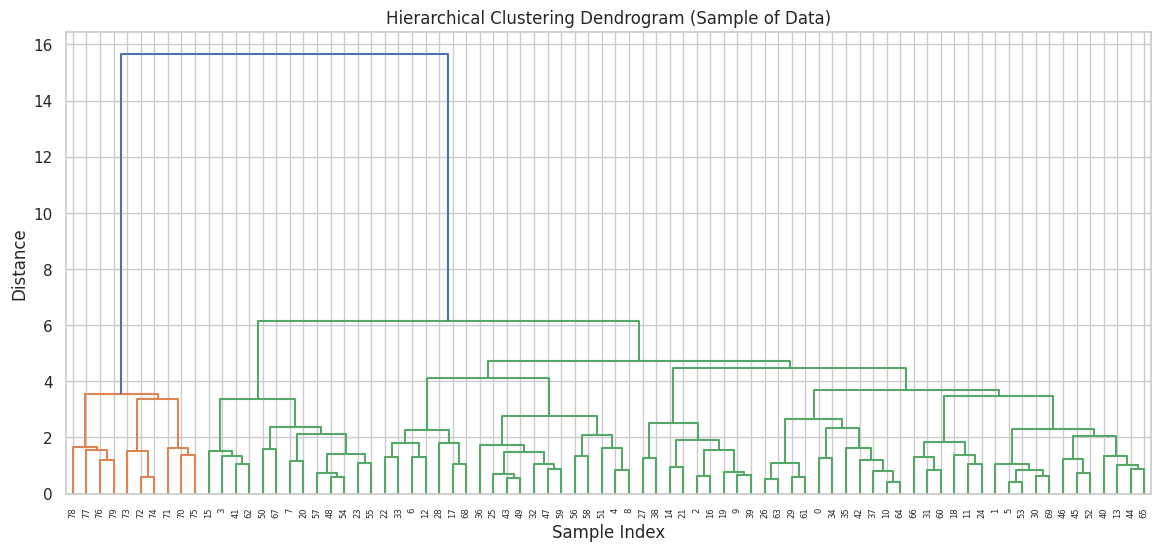

In [ ]:
# Dendrogram for hierarchical clustering
sample_size_for_dendrogram = min(80, X_dense.shape[0])
linkage_matrix = linkage(X_dense[:sample_size_for_dendrogram], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram (Sample of Data)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Use the same number of clusters for fair comparison
hierarchical_model = AgglomerativeClustering(n_clusters=int(best_k), linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_dense)

results["Hierarchical_Cluster"] = hierarchical_labels

hierarchical_silhouette = silhouette_score(X_dense, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", round(hierarchical_silhouette, 4))

Hierarchical Clustering Silhouette Score: 0.2605


In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Annual_Income_k$',
    y='Spending_Score',

    hue='KMeans_Cluster',
    data=results,  # Use the results DataFrame which has original features and cluster labels
    palette='viridis',
    s=100, # size of points
    alpha=0.8, # transparency
    edgecolor='w' # white edge for points
)
plt.title('K-Means Clusters based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='KMeans Cluster')
plt.grid(True)
plt.show()

SyntaxError: unterminated string literal (detected at line 6) (1253255378.py, line 6)

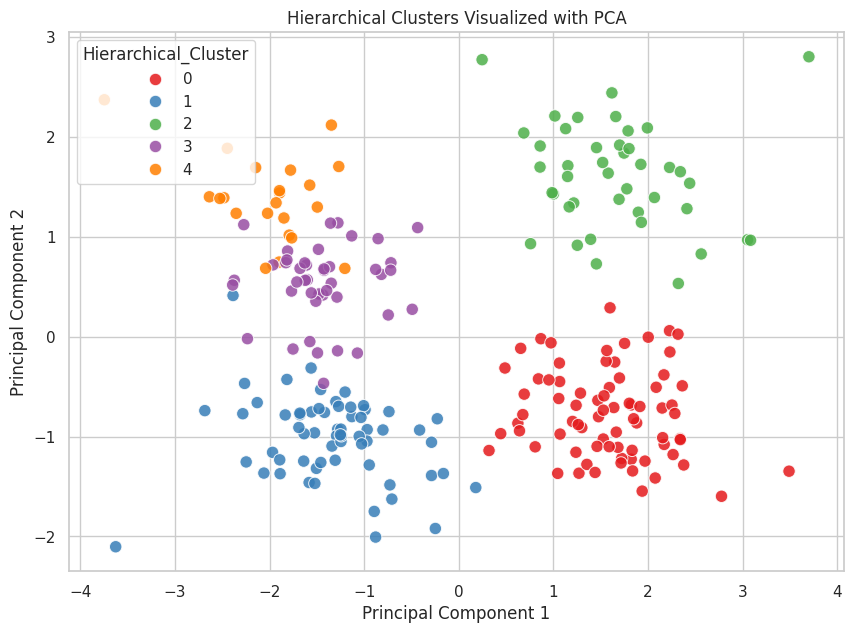

In [ ]:
# Visualize hierarchical clusters using the same PCA coordinates
pca_df["Hierarchical_Cluster"] = hierarchical_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Hierarchical_Cluster",
    palette="Set1",
    s=80,
    alpha=0.85
)
plt.title("Hierarchical Clusters Visualized with PCA")
plt.show()

In [ ]:
# Compare K-Means and Hierarchical cluster assignments
comparison_table = pd.crosstab(
    results["KMeans_Cluster"],
    results["Hierarchical_Cluster"],
    rownames=["KMeans"],
    colnames=["Hierarchical"]
)
comparison_table

Hierarchical,0,1,2,3,4
KMeans,,,,,
0,0,1,0,8,20
1,75,0,0,0,0
2,0,3,0,34,2
3,0,58,0,1,0
4,0,0,42,0,0


In [ ]:
# Hierarchical cluster profile
hierarchical_numeric_profile = results.groupby("Hierarchical_Cluster")[numeric_cols].mean().round(2)
hierarchical_categorical_profile = results.groupby("Hierarchical_Cluster")[categorical_cols].agg(
    lambda x: x.mode(dropna=True).iloc[0] if not x.mode(dropna=True).empty else np.nan
)

hierarchical_profile = hierarchical_numeric_profile.join(hierarchical_categorical_profile)
hierarchical_profile

,Age,Annual_Income_k$,Spending_Score,Visit_Frequency_per_Month,Online_Engagement_Score,Gender,Preferred_Section
Hierarchical_Cluster,,,,,,,
0,25.65,39.43,77.21,10.30,82.41,Female,Electronics
1,35.84,34.37,34.62,7.59,39.12,Female,Groceries
2,33.21,110.30,84.63,11.55,87.96,Female,Luxury
3,38.42,83.67,41.13,5.53,48.19,Male,Fashion
4,46.59,95.15,39.49,4.90,47.08,Female,Luxury
